## 'Welcome to "Marine Plastic Debris Detection"'

Marine plastic pollution is a big problem all across the globe. Large amounts of plastic waste end up in oceans and other water bodies. This leads to many issues like

- Death and injury of marine animals
- Destruction of marine habitats
- Consumption of plastic waste by marine animals
- Microplastic pollution
- Increase in toxic substances
- Water pollution
- Disturbance of marine ecosystems
- Plastic accumulation in oceans and coastal areas

With this, we want to use Computer Vision to create a simple tool that is going to detect and classify marine plastic debris in images to simplify the waste detection and management process. The tool can help identify plastic waste in marine environments and support efforts to keep oceans and water bodies clean.

## Data exploration
Data exploration uses visual exploration to explore dataset and understand the characteristics of the data. Now, let us visualize the data and see how the dataset is.

In [1]:
from keras.models import Sequential
from keras.layers import Conv2D
from keras.layers import MaxPooling2D
from keras.layers import Flatten
from keras.layers import Dense
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.preprocessing import image
from PIL import Image
import numpy as np
import os

Let us print some images onto the jupyter notebook

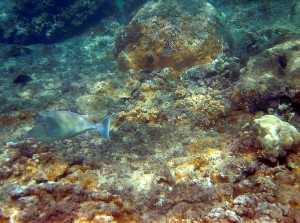

In [2]:
Image.open(r"D:\Marine plastic detection (R)\dataset_1\Corals\108085445_4c69912270_o.jpg")

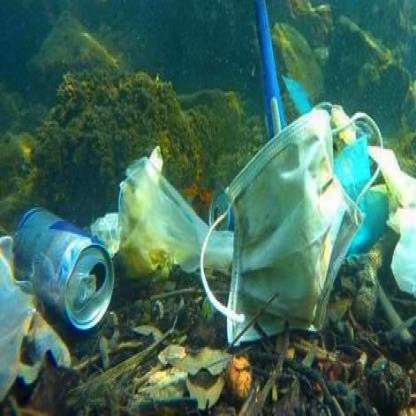

In [3]:
Image.open(r"D:\Marine plastic detection (R)\dataset_2\test\images\indl-ex_jpeg_jpg.rf.0f081bf9a06f0fa868a6cc09f7e60295.jpg")

To see the distribution , let us count the number of Marine Animals  and Plastic waste in the dataset

In [4]:
import os

DIR1 = r"D:\Marine plastic detection (R)\dataset_1"
DIR2 = r"D:\Marine plastic detection (R)\dataset_2\train"

extensions = (".jpg", ".jpeg", ".png", ".webp")

count1 = sum(
    1
    for root, dirs, files in os.walk(DIR1)
    for file in files
    if file.lower().endswith(extensions)
)

count2 = sum(
    1
    for root, dirs, files in os.walk(DIR2)
    for file in files
    if file.lower().endswith(extensions)
)

print("Dataset 1:", count1)
print("Dataset 2:", count2)

Dataset 1: 54844
Dataset 2: 3628


# Model Preparation

In [5]:
# Initialising the CNN
classifier = Sequential()

# Step 1 - Convolution
classifier.add(Conv2D(32, (3, 3), input_shape = (64, 64, 3),
                      activation = 'relu'))

# Step 2 - Pooling
classifier.add(MaxPooling2D(pool_size = (2, 2)))

# Adding a second convolutional layer
classifier.add(Conv2D(32, (3, 3), activation = 'relu'))
classifier.add(MaxPooling2D(pool_size = (2, 2)))

# Step 3 - Flattening
classifier.add(Flatten())

# Step 4 - Full connection
classifier.add(Dense(units = 128, activation = 'relu'))
classifier.add(Dense(units = 1, activation = 'sigmoid'))

# Compiling the CNN
classifier.compile(optimizer = 'adam', loss = 'binary_crossentropy',
                   metrics = ['accuracy'])

C:\Users\INDIA AI DATA LAB\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# Model Training
Now, the data generators are created and the model is trained.

In [6]:
train_datagen = ImageDataGenerator(rescale = 1./255)
test_datagen = ImageDataGenerator(rescale = 1./255)

In [7]:
training_set = train_datagen.flow_from_directory( r"D:\Marine plastic detection (R)\dataset_1\Train",
                                                 target_size = (64, 64),
                                                 batch_size = 32,
                                                 class_mode = 'binary')

test_set = test_datagen.flow_from_directory(   r"D:\Marine plastic detection (R)\dataset_2\train",
                                            target_size = (64, 64),
                                            batch_size = 32,
                                            class_mode = 'binary')

Found 13711 images belonging to 23 classes.
Found 3628 images belonging to 2 classes.


In [ ]:
classifier.fit(training_set,
                         steps_per_epoch = 706,
                         epochs = 4,
                         validation_data = test_set,
                         validation_steps = 2000)

Epoch 1/4
429/706 ━━━━━━━━━━━━━━━━━━━━ 1:04 235ms/step - accuracy: 0.0382 - loss: -436999268.2311

C:\Users\INDIA AI DATA LAB\AppData\Roaming\Python\Python312\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


706/706 ━━━━━━━━━━━━━━━━━━━━ 129s 181ms/step - accuracy: 0.0365 - loss: -2445782784.0000 - val_accuracy: 0.0000e+00 - val_loss: 1056958400.0000
Epoch 2/4
 83/706 ━━━━━━━━━━━━━━━━━━━━ 49s 79ms/step - accuracy: 0.0370 - loss: -16300877256.4819

# Model Testing
To test how the model is, it is now applied on a sample image.

In [ ]:
# organic image
test_image = image.load_img(r"D:\Marine plastic detection (R)\dataset_1\Test1\Dolphin\3861314696_98bdfcca65_b.jpg",
                            target_size = (64, 64))

In [ ]:
test_image = image.img_to_array(test_image)
test_image = np.expand_dims(test_image, axis = 0)
result = classifier.predict(test_image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step


In [ ]:
training_set.class_indices

{'Clams': 0,
 'Corals': 1,
 'Crabs': 2,
 'Dolphin': 3,
 'Eel': 4,
 'Fish': 5,
 'Jelly Fish': 6,
 'Lobster': 7,
 'Nudibranchs': 8,
 'Octopus': 9,
 'Otter': 10,
 'Penguin': 11,
 'Puffers': 12,
 'Sea Rays': 13,
 'Sea Urchins': 14,
 'Seahorse': 15,
 'Seal': 16,
 'Sharks': 17,
 'Shrimp': 18,
 'Squid': 19,
 'Starfish': 20,
 'Turtle_Tortoise': 21,
 'Whale': 22}

In [ ]:
if result[0][0] == 1:
    prediction = 'Marine Animals'
else:
    prediction = 'Plastic Watse'

In [ ]:
prediction

'Marine Animals'